### Clustering sobre datos PCA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

In [2]:
# =====================================================================
# 1. CARGA, PROCESAMIENTO Y ESCALAMIENTO
# =====================================================================
climate = pd.read_csv('../../data/climate.csv')
land = pd.read_csv('../../data/nhgis_county2022_tl2022_nlcd2021.csv')
land.columns = land.columns.str.lower()
climate['week_end'] = pd.to_datetime(climate['week_end'])
climate = climate.sort_values(by=['geoid', 'week_end'])

temp_wide = climate.pivot(index='geoid', columns='week_end', values='t_mean')
rh_wide = climate.pivot(index='geoid', columns='week_end', values='rh_mean')
wind_max = climate.groupby('geoid')['wind_speed_mean'].quantile(0.9).to_frame(name='wind_max')

land_cols = ['geoid', 'prop_11', 'prop_12', 'prop_21', 'prop_22', 'prop_23', 'prop_24',
             'prop_31', 'prop_41', 'prop_42', 'prop_43', 'prop_52', 'prop_71', 'prop_81',
             'prop_82', 'prop_90', 'prop_95']
land_filtered = land[land_cols].set_index('geoid')

# Crear macro-categorías sumando las proporciones del NLCD
land_grouped = pd.DataFrame(index=land_filtered.index)

land_grouped['urban_land'] = land_filtered[['prop_21', 'prop_22', 'prop_23', 'prop_24']].sum(axis=1)
land_grouped['forest_land'] = land_filtered[['prop_41', 'prop_42', 'prop_43']].sum(axis=1)
land_grouped['agricultural_land'] = land_filtered[['prop_81', 'prop_82']].sum(axis=1)
land_grouped['wetland'] = land_filtered[['prop_90', 'prop_95']].sum(axis=1)
land_grouped['shrubland'] = land_filtered['prop_52']
land_grouped['grassland'] = land_filtered['prop_71']
land_grouped['water_ice_cover'] = land_filtered[['prop_11', 'prop_12', 'prop_31']].sum(axis=1)

# qué hago con condados 110 condados que no tienen land cover registrada...?

# Sincronizar índices
common_geoids = temp_wide.index.intersection(land_grouped.index)
temp_wide = temp_wide.loc[common_geoids]
rh_wide = rh_wide.loc[common_geoids]
wind_max = wind_max.loc[common_geoids]
land_grouped = land_grouped.loc[common_geoids]

all_geoids = temp_wide.index

# Reducción de dimensionalidad aislada
temp_scaled = StandardScaler().fit_transform(temp_wide)
n_comp_temp = np.argmax(np.cumsum(PCA().fit(temp_scaled).explained_variance_ratio_) >= 0.90) + 1
df_temp_pca = pd.DataFrame(PCA(n_components=n_comp_temp).fit_transform(temp_scaled), 
                           index=common_geoids, columns=[f'temp_pca_{i+1}' for i in range(n_comp_temp)])

rh_scaled = StandardScaler().fit_transform(rh_wide)
n_comp_rh = np.argmax(np.cumsum(PCA().fit(rh_scaled).explained_variance_ratio_) >= 0.90) + 1
df_rh_pca = pd.DataFrame(PCA(n_components=n_comp_rh).fit_transform(rh_scaled), 
                          index=common_geoids, columns=[f'rh_pca_{i+1}' for i in range(n_comp_rh)])

# Matriz final para clustering
final_features_df = pd.concat([df_temp_pca, df_rh_pca, wind_max['wind_max'], land_grouped], axis=1)
X_clustering = StandardScaler().fit_transform(final_features_df)

# Guardar geoids como lista nativa de strings para el mapeo numérico posterior
geoids_list = [str(x).zfill(5) for x in common_geoids]

In [3]:
all_geoids = all_geoids.to_list()

In [4]:
# =====================================================================
# 2. DESCARGA DEL MAPA BASE DE EE.UU.
# =====================================================================
url = "https://www2.census.gov/geo/tiger/GENZ2021/shp/cb_2021_us_county_20m.zip"
usa = gpd.read_file(url)
usa['GEOID'] = usa['GEOID'].astype(str).str.zfill(5)

In [5]:
import numpy as np
import pandas as pd
import plotly.express as px

def eeuu_map(clusters, temp_real_df, geoids, model_name="", cluster_names=None, geojson_source='https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json'):
    """
    Genera un mapa interactivo de EE.UU. por condados con Plotly Express (sin usar usa_gdf).
    
    clusters: Array/Serie de etiquetas obtenidas del clustering.
    temp_real_df: DataFrame indexado por geoid con las columnas de las semanas (temp_wide).
    geoids: Lista o array ordenado de IDs de los condados (FIPS).
    model_name: Nombre del modelo o experimento para el título.
    cluster_names: (Opcional) Diccionario con nombres personalizados para cada cluster, ej: {0: 'Cálido Árido', ...}
    geojson_source: URL o ruta a un archivo JSON/GeoJSON local con los condados de EE.UU.
    """
    # 1. Calcular la temperatura media real a lo largo de las semanas
    if isinstance(temp_real_df, pd.DataFrame) and set(geoids).issubset(temp_real_df.index):
        temp_medias_por_condado = temp_real_df.loc[geoids].mean(axis=1).values
    else:
        temp_medias_por_condado = temp_real_df.mean(axis=1).values

    df_temp = pd.DataFrame({
        'cluster_original': clusters,
        'temp_media': temp_medias_por_condado
    })
    
    # 2. Re-etiquetado térmico (0 = Más cálido, N = Más frío)
    cluster_stats = df_temp.groupby('cluster_original')['temp_media'].mean().sort_values(ascending=False)
    reorder_map = {old_label: i for i, old_label in enumerate(cluster_stats.index)}
    new_clusters = np.array([reorder_map[label] for label in clusters])
    n_clusters = len(np.unique(new_clusters))
    
    # 3. Preparar DataFrame garantizando FIPS a 5 dígitos
    df_mapa = pd.DataFrame({
        'FIPS': pd.Series(geoids).astype(str).str.zfill(5),
        'cluster_num': new_clusters
    })

    # 4. Asignar etiquetas de leyenda
    if cluster_names:
        df_mapa['etiqueta'] = df_mapa['cluster_num'].apply(lambda x: cluster_names.get(x, f"Cluster {x}"))
    else:
        df_mapa['etiqueta'] = df_mapa['cluster_num'].apply(lambda x: f"Cluster {x}")

    # 5. Generar colores discretos usando la paleta RdYlBu (0 = Rojo/Cálido, K-1 = Azul/Frío)
    if n_clusters > 1:
        color_sequence = px.colors.sample_colorscale('RdYlBu', [i / (n_clusters - 1) for i in range(n_clusters)])
    else:
        color_sequence = ['#c1272d']

    label_order = [
        df_mapa[df_mapa['cluster_num'] == i]['etiqueta'].iloc[0] 
        for i in range(n_clusters) 
        if len(df_mapa[df_mapa['cluster_num'] == i]) > 0
    ]
    color_map = {label: color_sequence[i] for i, label in enumerate(label_order)}

    # 6. Crear mapa Choropleth
    title_text = f'<b>Climate clusters (K={n_clusters})</b>'
    if model_name:
        title_text += f'<br><sup>{model_name}</sup>'

    fig = px.choropleth(
        df_mapa,
        geojson=geojson_source,
        locations='FIPS',
        color='etiqueta',
        category_orders={'etiqueta': label_order},
        scope='usa',
        hover_data={'FIPS': True, 'etiqueta': True},
        color_discrete_map=color_map,
        title=title_text
    )

    fig.update_layout(
        title_x=0.5,
        legend_title_text='Cluster (Cálido → Frío)',
        margin={'r': 0, 't': 60, 'l': 0, 'b': 0},
        geo=dict(bgcolor='rgba(0,0,0,0)', lakecolor='white')
    )

    fig.show()

In [6]:
# # =====================================================================
# # 3. FUNCIÓN DE MAPEO
# # =====================================================================
# def eeuu_map(clusters, temp_real_df, geoids, usa_gdf, model_name=""):
#     """
#     clusters: Array de etiquetas obtenidas del clustering.
#     temp_real_df: DataFrame indexado por geoid con las columnas de las semanas (temp_wide).
#     geoids: Lista o array ordenado de IDs de los condados correspondiente a las filas de clusters.
#     usa_gdf: GeoDataFrame base del censo.
#     """
#     # 1. Calcular la temperatura media real a lo largo de las semanas para cada condado
#     temp_medias_por_condado = temp_real_df.mean(axis=1).values
    
#     df_temp = pd.DataFrame({
#         'cluster_original': clusters,
#         'temp_media': temp_medias_por_condado
#     })
    
#     # Ordenar los clusters de mayor a menor temperatura promedio
#     cluster_stats = df_temp.groupby('cluster_original')['temp_media'].mean().sort_values(ascending=False)
    
#     # 2. Crear mapeo de re-etiquetado térmico (0 = Más cálido)
#     reorder_map = {old_label: i for i, old_label in enumerate(cluster_stats.index)}
#     new_clusters = np.array([reorder_map[label] for label in clusters])
    
#     # 3. Preparar DataFrame para el merge
#     n_clusters = len(np.unique(new_clusters))
#     df_clusters = pd.DataFrame({'GEOID': geoids, 'cluster_ordenado': new_clusters})
    
#     # 4. Unir con geometrías y filtrar territorio continental
#     map_df = usa_gdf.merge(df_clusters, on='GEOID')
#     mainland = map_df[~map_df['STUSPS'].isin(['AK', 'HI', 'PR', 'GU', 'VI'])]

#     # 5. Configurar mapa
#     cmap_clima = plt.cm.get_cmap('RdYlBu')

#     fig, ax = plt.subplots(1, 1, figsize=(15, 10))
    
#     mainland.plot(column='cluster_ordenado', 
#                   cmap=cmap_clima,
#                   categorical=True, 
#                   legend=True,
#                   ax=ax,
#                   linewidth=0.1, 
#                   edgecolor='white',
#                   legend_kwds={'title': "Cluster no.", 
#                                'loc': 'lower right',
#                                'bbox_to_anchor': (1, 0)})

#     ax.set_title(f'Climate clusters (K={n_clusters})\n{model_name}', fontsize=16)
#     ax.axis('off')
    
#     plt.show()

In [7]:
from scipy.spatial.distance import cdist

def dunn_index(X, labels):
    # Obtener los clusters únicos (excluyendo ruido si lo hubiera)
    unique_labels = np.unique(labels)
    n_clusters = len(unique_labels)
    
    if n_clusters < 2:
        return 0.0
    
    # 1. Calcular los diámetros internos de cada cluster (máxima distancia interna)
    diameters = []
    for label in unique_labels:
        cluster_points = X[labels == label]
        if len(cluster_points) > 1:
            # Distancias par a par dentro del mismo cluster
            dists = cdist(cluster_points, cluster_points, metric='euclidean')
            diameters.append(np.max(dists))
        else:
            diameters.append(0.0)
    max_diameter = np.max(diameters)
    
    if max_diameter == 0:
        return 0.0
    
    # 2. Calcular la distancia mínima entre cualquier par de clusters diferentes
    min_inter_dist = np.inf
    for i in range(n_clusters):
        for j in range(i + 1, n_clusters):
            points_i = X[labels == unique_labels[i]]
            points_j = X[labels == unique_labels[j]]
            dists = cdist(points_i, points_j, metric='euclidean')
            min_dist = np.min(dists)
            if min_dist < min_inter_dist:
                min_inter_dist = min_dist
                
    # Índice de Dunn = Distancia Mínima Inter-Cluster / Diámetro Máximo Intra-Cluster
    return min_inter_dist / max_diameter

def discriminant_score(X, labels):
    unique_labels = np.unique(labels)
    n_clusters = len(unique_labels)
    if n_clusters < 2:
        return 0.0
    
    # Calcular centroides de cada cluster
    centroids = np.array([X[labels == label].mean(axis=0) for label in unique_labels])
    
    # Distancias entre todos los centroides
    centroid_dists = cdist(centroids, centroids, metric='euclidean')
    np.fill_diagonal(centroid_dists, np.inf) # Evitar distancia a sí mismo
    
    ds_per_cluster = []
    for idx, label in enumerate(unique_labels):
        cluster_points = X[labels == label]
        # Distancia media de los puntos de este cluster a su propio centroide
        avg_intra_dist = np.mean(cdist(cluster_points, centroids[idx].reshape(1, -1), metric='euclidean'))
        
        # Distancia al centroide vecino más cercano
        nearest_centroid_dist = np.min(centroid_dists[idx])
        
        # Discriminación local
        if nearest_centroid_dist > 0:
            score = (nearest_centroid_dist - avg_intra_dist) / max(nearest_centroid_dist, avg_intra_dist)
            ds_per_cluster.append(score)
            
    return np.mean(ds_per_cluster)

def quantization_error(X, labels):
    # Convertir a numpy array si viene como DataFrame para optimizar velocidad
    if hasattr(X, "values"):
        X = X.values
        
    unique_labels = np.unique(labels)
    # Filtrar etiquetas de ruido (como el -1 de DBSCAN/HDBSCAN) si existieran
    unique_labels = unique_labels[unique_labels != -1]
    
    total_distance = 0.0
    n_samples = len(X)
    
    for label in unique_labels:
        cluster_points = X[labels == label]
        if len(cluster_points) == 0:
            continue
        centroid = cluster_points.mean(axis=0).reshape(1, -1)
        distances = cdist(cluster_points, centroid, metric='euclidean')
        total_distance += np.sum(distances)
        
    qe_score = total_distance / n_samples
    
    return round(qe_score, 4)

In [8]:
def kmeans_clustering(X, n_clusters=5):
    model = KMeans(n_clusters=n_clusters, init='k-means++', random_state=0, n_init=10).fit(X)
    return model.labels_

def agglomerative_clustering(X, n_clusters=5, linkage='ward'):
    model = AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage).fit(X)
    return model.labels_

def gaussian_mixture_clustering(X, n_clusters=5, covariance_type="full"):
    model = GaussianMixture(n_components=n_clusters, covariance_type=covariance_type, random_state=42)
    labels = model.fit_predict(X)
    return labels

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# Lista para almacenar los registros de todas las iteraciones
registros_metricas = []

for n_clusters in range(5, 16):
    print(f"\n" + "="*50)
    print(f" EVALUANDO CONFIGURACIONES CON K = {n_clusters}")
    print("="*50)
    
    # 1. Generar etiquetas para cada algoritmo
    dict_modelos = {
        'KMeans': kmeans_clustering(X_clustering, n_clusters=n_clusters),
        'Agglomerative': agglomerative_clustering(X_clustering, n_clusters=n_clusters),
        'GaussianMixture': gaussian_mixture_clustering(X_clustering, n_clusters=n_clusters)
    }
    
    # 2. Calcular métricas para cada uno
    for nombre_modelo, etiquetas in dict_modelos.items():
        sil = round(silhouette_score(X_clustering, etiquetas, metric="euclidean"), 4)
        db = round(davies_bouldin_score(X_clustering, etiquetas), 4)
        ch = round(calinski_harabasz_score(X_clustering, etiquetas), 4)
        qe = round(quantization_error(X_clustering, etiquetas), 4)
        dunn = round(dunn_index(X_clustering, etiquetas), 4)
        ds = round(discriminant_score(X_clustering, etiquetas), 4)
        
        # Reportar resultados en consola
        print(f"\n[{nombre_modelo} - K={n_clusters}]")
        print(f"  > Silhouette Score:                 {sil}")
        print(f"  > Davies-Bouldin Index:             {db}")
        print(f"  > Calinski-Harabasz:                {ch}")
        print(f"  > Quantization Error:               {qe}")
        print(f"  > Dunn Index (Max):                 {dunn}")
        print(f"  > Discriminant Score (Max):         {ds}")
        
        # Guardar en la lista de registros
        registros_metricas.append({
            'Modelo': nombre_modelo,
            'K': n_clusters,
            'Silhouette': sil,
            'Davies-Bouldin': db,
            'Calinski-Harabasz': ch,
            'Quantization-Error': qe,
            'Dunn': dunn,
            'Discriminant-Score': ds
        })


 EVALUANDO CONFIGURACIONES CON K = 5

[KMeans - K=5]
  > Silhouette Score:                 0.1689
  > Davies-Bouldin Index:             1.8873
  > Calinski-Harabasz:                423.5844
  > Quantization Error:               3.4349
  > Dunn Index (Max):                 0.0191
  > Discriminant Score (Max):         0.0411

[Agglomerative - K=5]
  > Silhouette Score:                 0.1553
  > Davies-Bouldin Index:             1.9651
  > Calinski-Harabasz:                381.9452
  > Quantization Error:               3.4984
  > Dunn Index (Max):                 0.0287
  > Discriminant Score (Max):         0.0056

[GaussianMixture - K=5]
  > Silhouette Score:                 0.1147
  > Davies-Bouldin Index:             2.0656
  > Calinski-Harabasz:                330.1965
  > Quantization Error:               3.5352
  > Dunn Index (Max):                 0.0186
  > Discriminant Score (Max):         -0.01

 EVALUANDO CONFIGURACIONES CON K = 6

[KMeans - K=6]
  > Silhouette Score:        

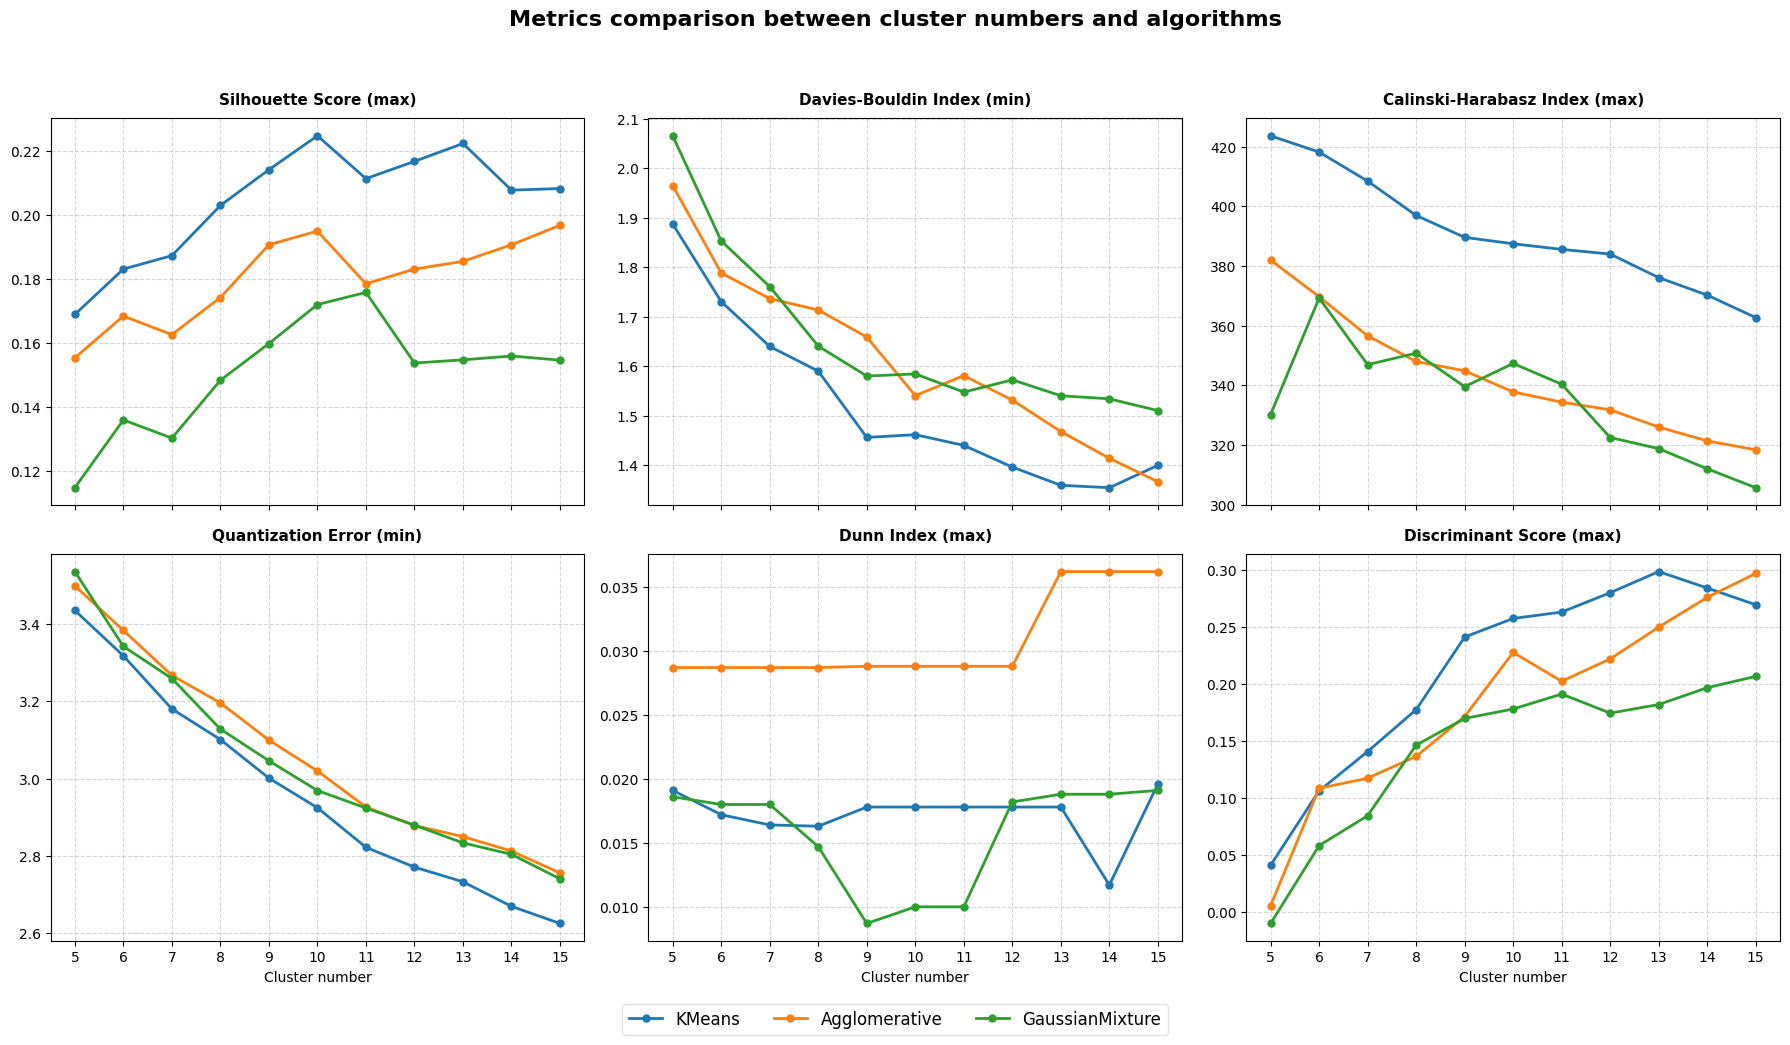

In [26]:
# ==============================================================================
# GENERACIÓN DE PLOTS (1 SOLA FIGURA GLOBAL CON MULTI-MODELOS)
# ==============================================================================

# Convertir registros a un DataFrame de Pandas
df_resultados = pd.DataFrame(registros_metricas)

# 1. Definir paleta de colores fija por MODELO para mantener la consistencia
colores_modelos = {
    'KMeans': '#1f77b4',          # Azul institucional
    'Agglomerative': '#ff7f0e',    # Naranja
    'GaussianMixture': '#2ca02c'   # Verde
}

# 2. Definir las métricas y sus títulos correspondientes
metricas_config = [
    ('Silhouette', 'Silhouette Score (max)'),
    ('Davies-Bouldin', 'Davies-Bouldin Index (min)'),
    ('Calinski-Harabasz', 'Calinski-Harabasz Index (max)'),
    ('Quantization-Error', 'Quantization Error (min)'),
    ('Dunn', 'Dunn Index (max)'),
    ('Discriminant-Score', 'Discriminant Score (max)')
]

# 3. Crear la estructura única en un Grid de 2 filas x 3 columnas
fig, axes = plt.subplots(2, 3, figsize=(18, 11), sharex=True)
fig.suptitle('Metrics comparison between cluster numbers and algorithms', fontsize=16, fontweight='bold', y=0.96)

# Obtener la lista de modelos únicos presentes en los datos
modelos_unicos = df_resultados['Modelo'].unique()

# 4. Mapear cada métrica a su respectivo cuadrante en el Grid
for ax, (columna, titulo) in zip(axes.flatten(), metricas_config):
    
    # Graficar la línea de cada modelo dentro del MISMO subplot
    for modelo in modelos_unicos:
        # Filtrar datos de este modelo específico y ordenarlos por K
        df_modelo = df_resultados[df_resultados['Modelo'] == modelo].sort_values('K')
        
        # Trazar la curva usando el color predefinido para este algoritmo
        ax.plot(
            df_modelo['K'], 
            df_modelo[columna], 
            marker='o', 
            linestyle='-', 
            color=colores_modelos.get(modelo, 'gray'), # Color por modelo
            linewidth=2, 
            markersize=5,
            label=modelo # Esto servirá para armar la leyenda posterior
        )
        
    # Formatear detalles estéticos por cuadrante
    ax.set_title(titulo, fontsize=11, fontweight='semibold', pad=10)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_xticks(range(5, 16))  # Forzar marcas del 5 al 15 exactas
    
    # Añadir etiqueta de eje X solo a la fila de abajo
    if ax in axes[1, :]:
        ax.set_xlabel('Cluster number', fontsize=10)

# 5. Añadir una leyenda única y limpia para toda la figura
# Tomamos los labels del último eje procesado para no duplicar entradas en la leyenda
handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles, 
    labels, 
    loc='lower center', 
    bbox_to_anchor=(0.5, 0.02), 
    ncol=3, 
    fontsize=12, 
    frameon=True,
    facecolor='white',
    edgecolor='gainsboro'
)

# Ajustar espaciado interno dejando margen abajo para la leyenda y arriba para el título
plt.tight_layout(rect=[0, 0.06, 1, 0.93])

plt.savefig('../../figures/climate_cluster_metrics.svg', format='svg')
plt.savefig('../../figures/climate_cluster_metrics.png', format='png')

plt.show()

In [13]:
import numpy as np
import pandas as pd
import plotly.express as px

def eeuu_map(
    clusters, 
    temp_real_df, 
    geoids, 
    model_name="", 
    cluster_names=None, 
    geojson_source='https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json'
):
    """
    Genera un mapa interactivo de EE.UU. por condados con Plotly Express, asignando a
    Alaska un cluster propio posicionado como el más frío (azul más intenso).
    """
    # 1. Formatear FIPS a 5 dígitos
    geoids_series = pd.Series(geoids).astype(str).str.zfill(5)
    
    df_base = pd.DataFrame({
        'FIPS': geoids_series.values,
        'cluster_original': clusters
    })
    
    # 2. Separar condados de CONUS de los de Alaska (FIPS de Alaska empiezan con '02')
    is_alaska = df_base['FIPS'].str.startswith('02')
    df_conus = df_base[~is_alaska].copy()
    df_ak_input = df_base[is_alaska].copy()
    
    # 3. Re-etiquetado térmico solo para CONUS (0 = Más cálido, K-1 = Más frío)
    if isinstance(temp_real_df, pd.DataFrame):
        conus_fips_valid = df_conus['FIPS'][df_conus['FIPS'].isin(temp_real_df.index)]
        temp_means = temp_real_df.loc[conus_fips_valid].mean(axis=1)
        temp_means_df = pd.DataFrame({'FIPS': conus_fips_valid, 'temp_media': temp_means.values})
        df_conus = df_conus.merge(temp_means_df, on='FIPS', how='left')
    else:
        df_conus['temp_media'] = temp_real_df[~is_alaska]
        
    cluster_stats = df_conus.groupby('cluster_original')['temp_media'].mean().sort_values(ascending=False)
    reorder_map = {old_label: i for i, old_label in enumerate(cluster_stats.index)}
    
    df_conus['cluster_num'] = df_conus['cluster_original'].map(reorder_map)
    n_conus_clusters = len(cluster_stats)
    
    # 4. Asignar Alaska al cluster K (el más frío de todos)
    ak_cluster_num = n_conus_clusters
    
    if len(df_ak_input) > 0:
        df_ak = df_ak_input.copy()
        df_ak['cluster_num'] = ak_cluster_num
    else:
        # Si Alaska no venía en geoids, inyectamos los FIPS estándar de sus boroughs
        ak_fips_list = [
            '02013', '02016', '02020', '02050', '02060', '02068', '02070', '02090', 
            '02100', '02105', '02110', '02122', '02130', '02150', '02164', '02170', 
            '02180', '02185', '02188', '02195', '02198', '02220', '02230', '02240', 
            '02261', '02275', '02282', '02290'
        ]
        df_ak = pd.DataFrame({'FIPS': ak_fips_list, 'cluster_num': ak_cluster_num})
        
    df_mapa = pd.concat([df_conus[['FIPS', 'cluster_num']], df_ak[['FIPS', 'cluster_num']]], ignore_index=True)
    
    # 5. Mapear nombres de las etiquetas en la leyenda
    total_clusters = n_conus_clusters + 1
    
    def get_cluster_label(c_num):
        if c_num == ak_cluster_num:
            return "Alaska"
        elif cluster_names and c_num in cluster_names:
            return cluster_names[c_num]
        else:
            return f"Cluster {c_num}"
            
    df_mapa['etiqueta'] = df_mapa['cluster_num'].apply(get_cluster_label)
    
    # 6. Muestrear paleta RdYlBu para total_clusters (Rojo = Cálido, Azul Oscuro = Alaska)
    color_sequence = px.colors.sample_colorscale('RdYlBu', [i / (total_clusters - 1) for i in range(total_clusters)])
    
    label_order = []
    for i in range(total_clusters):
        sub = df_mapa[df_mapa['cluster_num'] == i]
        if len(sub) > 0:
            label_order.append(sub['etiqueta'].iloc[0])
            
    color_map = {label_order[i]: color_sequence[i] for i in range(len(label_order))}

    # 7. Construir y desplegar mapa Choropleth
    title_text = f'<b>Climate clusters (K={total_clusters})</b>'
    if model_name:
        title_text += f'<br><sup>{model_name}</sup>'

    fig = px.choropleth(
        df_mapa,
        geojson=geojson_source,
        locations='FIPS',
        color='etiqueta',
        category_orders={'etiqueta': label_order},
        scope='usa',
        hover_data={'FIPS': True, 'etiqueta': True},
        color_discrete_map=color_map,
        title=title_text
    )

    fig.update_layout(
        title_x=0.5,
        legend_title_text='Cluster',
        margin={'r': 0, 't': 60, 'l': 0, 'b': 0},
        geo=dict(bgcolor='rgba(0,0,0,0)', lakecolor='white')
    )

    # Configurar el botón de la cámara para descargar en formato SVG o PNG en alta resolución
    fig.show(config={
        'toImageButtonOptions': {
            'format': 'svg', # O cambiar por 'png'
            'filename': 'climate_cluster_map',
            'height': 800,
            'width': 1200,
            'scale': 2 # Escala x2 para alta resolución
        }
    })

    # Configurar el botón de la cámara para descargar en formato SVG o PNG en alta resolución
    fig.show(config={
        'toImageButtonOptions': {
            'format': 'png', # O cambiar por 'png'
            'filename': 'climate_cluster_map',
            'height': 800,
            'width': 1200,
            'scale': 2 # Escala x2 para alta resolución
        }
    })

In [14]:
# Definición de las configuraciones óptimas seleccionadas
configuraciones_campeonas = [
    {
        'name': 'KMeans',
        'k': 13,
        'labels': kmeans_clustering(X_clustering, n_clusters=13),
        'sil': 0.2224
    }#,
    # {
    #     'name': 'Agglomerative',
    #     'k': 10,
    #     'labels': agglomerative_clustering(X_clustering, n_clusters=10),
    #     'sil': 0.195
    # },
    # {
    #     'name': 'GaussianMixture',
    #     'k': 11,
    #     'labels': gaussian_mixture_clustering(X_clustering, n_clusters=11),
    #     'sil': 0.1758
    # }
]

# Renderizado automático de mapas óptimos
for modelo in configuraciones_campeonas:
    print(f"Generando mapa óptimo para {modelo['name']} (K={modelo['k']})...")
    
    # Llamada a tu función de mapeo usando la temperatura real (temp_wide)
    eeuu_map(
        clusters=modelo['labels'], 
        temp_real_df=temp_wide, 
        geoids=geoids_list, 
        # usa_gdf=usa, 
        model_name=f"{modelo['name']} clustering - PCA-reduced time series (Silhouette: {modelo['sil']})"
    )

Generando mapa óptimo para KMeans (K=13)...


In [15]:
import numpy as np
import pandas as pd

def reencode_labs(clusters, temp_real_df, geoids):
    """
    Re-etiqueta térmicamente los clusters (0 = Más cálido, K-1 = Más frío en CONUS).
    Asigna a todos los condados/boroughs de Alaska un cluster adicional K (el más frío).
    """
    # 1. Normalizar FIPS a cadenas de 5 dígitos
    geoids_series = pd.Series(geoids).astype(str).str.zfill(5)
    clusters_arr = np.array(clusters)
    
    # Lista de FIPS estándar para Alaska
    ak_fips_list = [
        '02013', '02016', '02020', '02050', '02060', '02068', '02070', '02090', 
        '02100', '02105', '02110', '02122', '02130', '02150', '02164', '02170', 
        '02180', '02185', '02188', '02195', '02198', '02220', '02230', '02240', 
        '02261', '02275', '02282', '02290'
    ]
    
    # 2. Máscara booleana (usamos .values para evitar conflictos de índice)
    is_alaska_mask = geoids_series.str.startswith('02').values
    
    df_conus = pd.DataFrame({
        'geoid': geoids_series[~is_alaska_mask].values,
        'cluster_original': clusters_arr[~is_alaska_mask]
    })
    
    # 3. Calcular la temperatura media de CONUS evitando desalineaciones de índice
    if isinstance(temp_real_df, pd.DataFrame) and set(df_conus['geoid']).issubset(temp_real_df.index):
        temp_means = temp_real_df.loc[df_conus['geoid']].mean(axis=1).values
    else:
        # Extraemos el array numpy directamente con .values
        temp_means = temp_real_df.values[~is_alaska_mask].mean(axis=1)
        
    df_conus['temp_media'] = temp_means
    
    # 4. Ordenar los clusters de CONUS de mayor a menor temperatura promedio
    cluster_stats = df_conus.groupby('cluster_original')['temp_media'].mean().sort_values(ascending=False)
    reorder_map = {old_label: i for i, old_label in enumerate(cluster_stats.index)}
    
    df_conus['new_cluster'] = df_conus['cluster_original'].map(reorder_map)
    n_conus_clusters = len(cluster_stats)
    
    # 5. Definir el cluster de Alaska como K (el más frío)
    ak_cluster_label = n_conus_clusters
    
    # 6. Manejar condados de Alaska
    if is_alaska_mask.any():
        df_alaska = pd.DataFrame({
            'geoid': geoids_series[is_alaska_mask].values,
            'cluster_original': clusters_arr[is_alaska_mask],
            'temp_media': -999.0,
            'new_cluster': ak_cluster_label
        })
    else:
        df_alaska = pd.DataFrame({
            'geoid': ak_fips_list,
            'cluster_original': -1,
            'temp_media': -999.0,
            'new_cluster': ak_cluster_label
        })
        
    df_final = pd.concat([df_conus, df_alaska], ignore_index=True)
    
    return df_final['new_cluster'].values, df_final['geoid'].values

In [16]:
# Definición de las configuraciones óptimas seleccionadas
modelo = {
    'name': 'KMeans',
    'k': 13,
    'labels': kmeans_clustering(X_clustering, n_clusters=13)
}

labs_reencoded = reencode_labs(modelo['labels'], temp_wide, geoids_list)

In [17]:
import pandas as pd

# =====================================================================
# 1. NORMALIZAR ÍNDICES DE LOS DATAFRAMES ORIGINALE A STRING (5 DIGITOS)
# =====================================================================
# Esto resuelve el conflicto entre enteros (1001) y strings ('01001')
temp_wide.index = temp_wide.index.astype(str).str.zfill(5)
rh_wide.index = rh_wide.index.astype(str).str.zfill(5)
wind_max.index = wind_max.index.astype(str).str.zfill(5)
land_grouped.index = land_grouped.index.astype(str).str.zfill(5)

# =====================================================================
# 2. DESEMPAQUETAR LABS_REENCODED
# =====================================================================
# labs_reencoded[0] -> Etiquetas de clusters (array int)
# labs_reencoded[1] -> GEOIDs/FIPS actualizados (array str 5 dígitos)
cluster_labels, geoids_updated = labs_reencoded

# =====================================================================
# 3. CONSTRUCCIÓN DE DF_ORIGINAL (MEDIAS EN UNIDADES REALES)
# =====================================================================
# Usamos geoids_updated como el índice maestro de df_original
df_original = pd.DataFrame(index=geoids_updated)

# Reducir series temporales
df_original['temp_media_anual'] = temp_wide.mean(axis=1).reindex(geoids_updated)
df_original['temp_max_absoluta'] = temp_wide.max(axis=1).reindex(geoids_updated)
df_original['temp_min_absoluta'] = temp_wide.min(axis=1).reindex(geoids_updated)

df_original['humedad_media_anual'] = rh_wide.mean(axis=1).reindex(geoids_updated)
df_original['humedad_min_absoluta'] = rh_wide.min(axis=1).reindex(geoids_updated)

df_original['viento_max_percentil90'] = wind_max['wind_max'].reindex(geoids_updated)

# Macro-Categorías de Suelo (% real)
for col in land_grouped.columns:
    df_original[col] = (land_grouped[col] * 100).reindex(geoids_updated)

# Identificador explícito
df_original['geoid_str'] = geoids_updated

# =====================================================================
# 4. CONSTRUCCIÓN DE LA TABLA DE PERFILES POR CLUSTER
# =====================================================================
df_perfiles = df_original.copy()

# Inyectamos la columna de Cluster
df_perfiles['Cluster'] = cluster_labels

# Seleccionamos variables numéricas
columnas_interes = [
    'temp_media_anual', 'temp_max_absoluta', 'temp_min_absoluta',
    'humedad_media_anual', 'humedad_min_absoluta', 'viento_max_percentil90'
] + list(land_grouped.columns)

# Agrupamos por Cluster y calculamos las medias
df_filtrado = df_perfiles[columnas_interes + ['Cluster']]
tabla_medias = df_filtrado.groupby('Cluster').mean()

# Si Alaska fue inyectada al final (ej. Cluster K), renombramos su etiqueta para claridad
total_k = len(tabla_medias)
if (total_k - 1) in tabla_medias.index:
    tabla_medias = tabla_medias.rename(index={total_k - 1: f"{total_k - 1} (Alaska)"})

# Transponemos para lectura limpia (Variables en filas, Clusters en columnas)
tabla_perfiles_final = tabla_medias.T

# Formato visual elegante
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print("\n" + "="*80)
print(" CÉDULA DE IDENTIDAD DE LOS CLUSTERS (MEDIAS REALES)")
print("="*80)
print(tabla_perfiles_final)
print("="*80 + "\n")


 CÉDULA DE IDENTIDAD DE LOS CLUSTERS (MEDIAS REALES)
Cluster                    0     1     2     3     4     5     6      7  \
temp_media_anual       20.66 20.22 19.79 15.87 15.44 14.39 14.25  13.81   
temp_max_absoluta      33.83 32.70 30.02 28.30 30.35 29.72 28.22  28.30   
temp_min_absoluta       0.98 -0.75  2.21 -4.75 -1.77  1.90 -5.87 -10.06   
humedad_media_anual    54.50 73.43 76.38 74.94 41.15 61.31 75.13  73.58   
humedad_min_absoluta   27.98 42.18 56.38 50.66 13.66 20.34 52.93  49.65   
viento_max_percentil90 18.39 15.29 14.00 13.27 14.98 11.34 14.54  16.29   
urban_land              3.25  7.81 10.98  9.71  2.38  9.40 64.95   9.69   
forest_land             5.28 34.78 22.66 61.93 14.73 24.21 18.41  18.97   
agricultural_land      17.42 28.96 20.77 19.28  1.78 14.03  8.26  64.87   
wetland                 0.63 13.34 34.93  2.67  0.51  1.72  4.62   4.00   
shrubland              60.01  4.37  3.68  2.02 65.57 28.37  0.47   0.20   
grassland              12.61  7.74  3.07  2.41

In [18]:
cluster_mapping = {
    0: "Hot Windy Arid Shrubland",                 # 20.7°C, high wind (18.39), 60.0% shrubland
    1: "Warm Humid Subtropical Ag-Forest",         # 20.2°C, 73.4% RH, 34.8% forest, 29.0% agriculture
    2: "Warm Maritime Swampland & Wetland",        # 19.8°C, high RH (76.4%), highest wetland (34.9%)
    3: "Mild Humid Dense Forest",                  # 15.9°C, high RH (74.9%), highest forest cover (61.9%)
    4: "Mild Hyper-Dry Scrub & Basins",            # 15.4°C, lowest min RH (13.7%), 65.6% shrubland
    5: "Temperate Mild Mixed Rangeland",           # 14.4°C, lowest wind (11.34), 28.4% shrub, 24.2% forest
    6: "Temperate Highly Urbanized Hubs",          # 14.3°C, 65.0% urban land (Metropolitan Corridors)
    7: "Temperate Humid Corn Belt Agriculture",    # 13.8°C, 64.9% agricultural land, cold winters (-10.1°C)
    8: "Cool Windy Semiarid Prairie Grassland",    # 13.3°C, high wind (17.97), 50.5% grassland
    9: "Cold Extreme-Winter Agricultural Plains",  # 10.0°C, min temp -18.1°C, high wind (18.23), 70.0% Ag
    10: "Cold Mountain Foothill & Forest Fringe",  # 9.5°C, 42.7% forest, 17.1% shrubland
    11: "Cold Hyper-Humid North Woods",            # 9.5°C, highest avg RH (80.2%), 53.0% forest, 13.5% wetland
    12: "Cold Dry High-Elevation Steppe",           # 7.0°C, low min RH (26.5%), 40.3% shrub, 28.6% forest
    13: "Alaska"
}

In [19]:
df_final = pd.DataFrame({
    'geoid': geoids_updated,
    'cluster': cluster_labels
})

df_final['description'] = df_final['cluster'].map(cluster_mapping)
print(df_final.head())

   geoid  cluster                        description
0  01001        3            Mild Humid Dense Forest
1  01003        2  Warm Maritime Swampland & Wetland
2  01005        3            Mild Humid Dense Forest
3  01007        3            Mild Humid Dense Forest
4  01009        3            Mild Humid Dense Forest


In [21]:
import numpy as np
import pandas as pd
import plotly.express as px

# =====================================================================
# 1. PREPARE DATA WITH CLUSTER NAMES
# =====================================================================
df_map = df_final.copy()
df_map['geoid'] = df_map['geoid'].astype(str).str.zfill(5)

# Append Alaska to mapping dictionary if not present
cluster_mapping_full = cluster_mapping.copy()
# cluster_mapping_full[13] = "Cold Alaska Region"

# Ensure all clusters get formatted names (e.g., "0: Hot Windy Arid Shrubland")
def format_label(c_id):
    name = cluster_mapping_full.get(c_id, f"Cluster {c_id}")
    return f"{c_id}: {name}"

df_map['etiqueta'] = df_map['cluster'].map(format_label)

# Ensure proper numeric ordering (0 -> 13) for the legend
df_map = df_map.sort_values(by='cluster')
unique_clusters = sorted(df_map['cluster'].unique())
label_order = [format_label(c) for c in unique_clusters]

# =====================================================================
# 2. COLOR PALETTE (Warm to Cold Scale: Red -> Yellow -> Blue)
# =====================================================================
n_clusters = len(unique_clusters)
color_sequence = px.colors.sample_colorscale(
    'RdYlBu', 
    [i / max(1, n_clusters - 1) for i in range(n_clusters)]
)
color_map = {label_order[i]: color_sequence[i] for i in range(n_clusters)}

# =====================================================================
# 3. BUILD USA ALBERS PROJECTION MAP
# =====================================================================
fig = px.choropleth(
    df_map,
    geojson='https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json',
    locations='geoid',
    color='etiqueta',
    category_orders={'etiqueta': label_order},
    color_discrete_map=color_map,
    scope='usa',  # Automatically hides Mexico/Canada & moves Alaska to bottom-left
    hover_data={'geoid': True, 'cluster': True, 'description': True, 'etiqueta': False},
    labels={
        'geoid': 'FIPS',
        'cluster': 'Cluster ID',
        'description': 'Description',
        'etiqueta': 'Cluster'
    }
)

fig.update_layout(
    title_text="<b>US Counties Climate & Land Cover Clusters</b>",
    title_x=0.5,
    legend_title_text='<b>Cluster</b>',
    margin={'r': 0, 't': 50, 'l': 0, 'b': 0},
    geo=dict(
        bgcolor='rgba(0,0,0,0)',
        lakecolor='rgba(255,255,255,1)',
        showlakes=True
    )
)



# Configurar el botón de la cámara para descargar en formato SVG o PNG en alta resolución
fig.show(config={
    'toImageButtonOptions': {
        'format': 'svg', # O cambiar por 'png'
        'filename': 'climate_cluster_map',
        'height': 800,
        'width': 1200,
        'scale': 2 # Escala x2 para alta resolución
    }
})



# Configurar el botón de la cámara para descargar en formato SVG o PNG en alta resolución
fig.show(config={
    'toImageButtonOptions': {
        'format': 'png', # O cambiar por 'png'
        'filename': 'climate_cluster_map',
        'height': 800,
        'width': 1200,
        'scale': 2 # Escala x2 para alta resolución
    }
})

In [48]:
len(geoids_updated)

3128

In [49]:
import us
fips_url = 'https://www2.census.gov/geo/docs/reference/codes/files/national_county.txt'
fips_df = pd.read_csv(fips_url, header=None, names=['state', 'state_fips', 'county_fips', 'county_name', 'class code'], dtype=str)
fips_df['fips'] = fips_df['state_fips'] + fips_df['county_fips']
fips_df['county_name'] = fips_df['county_name'].str.lower()
fips_df['state_name'] = fips_df['state'].apply(lambda x: us.states.lookup(x).name.lower() if us.states.lookup(x) else None)

fips_df.head()

,state,state_fips,county_fips,county_name,class code,fips,state_name
0,AL,01,001,autauga county,H1,01001,alabama
1,AL,01,003,baldwin county,H1,01003,alabama
2,AL,01,005,barbour county,H1,01005,alabama
3,AL,01,007,bibb county,H1,01007,alabama
4,AL,01,009,blount county,H1,01009,alabama


In [50]:
df_final_2 = df_final.merge(fips_df[['fips', 'state_name', 'county_name']], left_on='geoid', right_on='fips')
df_final_2 = df_final_2[['geoid', 'state_name', 'county_name', 'cluster', 'description']]
df_final_2.head()

,geoid,state_name,county_name,cluster,description
0,01001,alabama,autauga county,3,Mild Humid Dense Forest
1,01003,alabama,baldwin county,2,Warm Maritime Swampland & Wetland
2,01005,alabama,barbour county,3,Mild Humid Dense Forest
3,01007,alabama,bibb county,3,Mild Humid Dense Forest
4,01009,alabama,blount county,3,Mild Humid Dense Forest


In [51]:
df_final_2.to_csv('../../data/climate_cluster.csv', index=False)

In [52]:
land_grouped = land_grouped.reset_index()
land_grouped['geoid'] = land_grouped['geoid'].astype(str).str.zfill(5)
land_grouped_2 = land_grouped.merge(fips_df[['fips', 'state_name', 'county_name']], left_on='geoid', right_on='fips')
land_grouped_2 = land_grouped_2[['geoid', 'state_name', 'county_name'] + list(land_grouped.columns[-7:])]
land_grouped_2.head()

,geoid,state_name,county_name,urban_land,forest_land,agricultural_land,wetland,shrubland,grassland,water_ice_cover
0,01001,alabama,autauga county,0.07,0.49,0.18,0.11,0.06,0.07,0.02
1,01003,alabama,baldwin county,0.10,0.33,0.15,0.30,0.05,0.04,0.03
2,01005,alabama,barbour county,0.04,0.58,0.13,0.09,0.08,0.05,0.02
3,01007,alabama,bibb county,0.05,0.70,0.05,0.07,0.05,0.07,0.01
4,01009,alabama,blount county,0.09,0.55,0.29,0.01,0.02,0.03,0.01


In [53]:
land_grouped_2.to_csv('../../data/land_cover.csv', index=False)

In [54]:
land_grouped

,geoid,urban_land,forest_land,agricultural_land,wetland,shrubland,grassland,water_ice_cover
0,01001,0.07,0.49,0.18,0.11,0.06,0.07,0.02
1,01003,0.10,0.33,0.15,0.30,0.05,0.04,0.03
2,01005,0.04,0.58,0.13,0.09,0.08,0.05,0.02
3,01007,0.05,0.70,0.05,0.07,0.05,0.07,0.01
4,01009,0.09,0.55,0.29,0.01,0.02,0.03,0.01
...,...,...,...,...,...,...,...,...
3095,56037,0.01,0.00,0.00,0.00,0.89,0.05,0.04
3096,56039,0.01,0.46,0.00,0.04,0.37,0.06,0.06
3097,56041,0.02,0.07,0.06,0.05,0.72,0.04,0.04
3098,56043,0.01,0.05,0.03,0.01,0.70,0.19,0.01
